# Optimized FCL Experiments

This notebook contains optimized experiments for Federated Continual Learning with:
- Multiple model sizes (tiny, small, medium, large)
- Multiple loss functions (MSE, MAPE, LWWN, Wasserstein, etc.)
- Persistent homology analysis
- Random matrix theory metrics
- WandB integration for tracking

**Goal**: Compete with state-of-the-art hyper-representation methods while maintaining efficient training on RTX 5060 Ti (16GB VRAM)

## Setup and Imports

In [1]:
import sys
import os
from pathlib import Path

# Add parent directory to path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Custom imports
from config import (
    MODEL_CONFIGS, 
    create_experiment_config, 
    print_config_summary,
    EXPERIMENT_SUITE
)
from optimized_models import OptimizedTransformerAE, create_model_from_config
from loss_functions import get_loss_function, MultiLoss
from trainer import FCLTrainer, create_dataloaders
from testing_suite import WeightComparator, run_comprehensive_test
from topology_analysis import PersistentHomologyAnalyzer, BettiCurveAnalyzer
from rmt_analysis import RandomMatrixAnalyzer

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 16.61 GB


## Model Size Comparison

Compare parameter counts and estimated memory usage for different model sizes

In [2]:
print("Available Model Configurations:")
print("=" * 80)

model_comparison = []

for name, config in MODEL_CONFIGS.items():
    # Create model to get actual parameter count
    model = create_model_from_config(config)
    actual_params = model.count_parameters()
    estimated_params = config.get_param_count_estimate()
    
    # Estimate memory (params * 4 bytes for float32 + activations)
    param_memory_mb = (actual_params * 4) / 1e6
    total_memory_mb = param_memory_mb * 3  # Rough estimate with gradients and optimizer states
    
    model_comparison.append({
        'name': name,
        'params': actual_params,
        'estimated_params': estimated_params,
        'param_memory_mb': param_memory_mb,
        'total_memory_mb': total_memory_mb,
        'N': config.N,
        'heads': config.heads,
        'd_model': config.d_model,
        'd_ff': config.d_ff,
        'neck': config.neck
    })
    
    print(f"{name:10s}: {actual_params/1e6:8.2f}M params | "
          f"Memory: ~{total_memory_mb:.0f}MB | "
          f"N={config.N}, heads={config.heads}, d_model={config.d_model}")
    
    del model
    torch.cuda.empty_cache()

# Create comparison dataframe
df_models = pd.DataFrame(model_comparison)
df_models

Available Model Configurations:
tiny      :     4.02M params | Memory: ~48MB | N=1, heads=2, d_model=32
small     :     8.32M params | Memory: ~100MB | N=2, heads=4, d_model=64
medium    :    18.06M params | Memory: ~217MB | N=3, heads=4, d_model=128
large     :    42.98M params | Memory: ~516MB | N=4, heads=8, d_model=256
huge      :   127.56M params | Memory: ~1531MB | N=6, heads=8, d_model=512


,name,params,estimated_params,param_memory_mb,total_memory_mb,N,heads,d_model,d_ff,neck
0,tiny,4020752,4088192,16.083008,48.249024,1,2,32,128,16
1,small,8322112,8457728,33.288448,99.865344,2,4,64,256,32
2,medium,18063968,18334208,72.255872,216.767616,3,4,128,512,64
3,large,42983968,43520000,171.935872,515.807616,4,8,256,1024,128
4,huge,127555232,128602112,510.220928,1530.662784,6,8,512,2048,256


## Loss Function Testing

Test all loss functions on sample data

In [3]:
# Create sample data
torch.manual_seed(42)
batch_size = 4
weight_dim = 2464
latent_dim = 64

predicted = torch.randn(batch_size, weight_dim) * 0.1
target = torch.randn(batch_size, weight_dim) * 0.1
latent = torch.randn(batch_size, latent_dim) * 0.1

# Test each loss function
loss_results = {}

loss_names = ['mse', 'mape', 'auto', 'lwwn', 'lwwn_ws', 'wasserstein', 'latent']

print("Loss Function Comparison:")
print("=" * 60)

for loss_name in loss_names:
    loss_fn = get_loss_function(loss_name)
    
    if loss_name in ['auto', 'latent']:
        loss_value = loss_fn(predicted, target, latent)
    else:
        loss_value = loss_fn(predicted, target)
    
    loss_results[loss_name] = loss_value.item()
    print(f"{loss_name:15s}: {loss_value.item():.6f}")

# Test multi-loss
print("\nMulti-Loss (weighted combination):")
multi_loss = MultiLoss()
total_loss, loss_dict = multi_loss(predicted, target, latent)

for name, value in loss_dict.items():
    print(f"  {name:15s}: {value:.6f}")

Loss Function Comparison:
mse            : 0.020309
mape           : 6.087333
auto           : 0.020401
lwwn           : 0.023308
lwwn_ws        : 2.319872
wasserstein    : 0.070414
latent         : 0.021782

Multi-Loss (weighted combination):
  mse            : 0.020309
  mape           : 6.087333
  wasserstein    : 0.076393
  latent         : 0.021782
  total          : 0.635041


## Quick Experiment: Tiny Model

Run a quick experiment with the tiny model to verify everything works

In [4]:
# Create experiment configuration
config = create_experiment_config(
    model_size="tiny",
    overlap=2,
    primary_loss="mse",
    experiment_name="quick_test_tiny"
)

# Reduce epochs for quick test
config.training.epochs = 5
config.training.log_every = 5
config.data.batch_limit = 10  # Limit batches for quick test

print_config_summary(config)

# Create model
model = create_model_from_config(config.model)
print(f"\n{model.numParams()}")


Experiment: quick_test_tiny

Model: tiny
  - Estimated params: 4.09M
  - Layers: 1, Heads: 2
  - d_model: 32, d_ff: 128
  - Neck: 16, Dropout: 0.1

Data:
  - Batch size: 32
  - Overlap levels: [2]
  - Activation: silu

Training:
  - Epochs: 5
  - Learning rate: 0.0001
  - Device: cuda
  - Mixed precision: True

Loss:
  - Primary: mse
  - Multi-loss: True

Metrics:
  - Persistent Homology: True
  - RMT: True


EncParams: 15,904, NeckParams: 4,112, DecParams: 3,984,832, || ModelParams: 4,020,752


In [5]:
# Note: This cell requires preprocessed data
# Run data_preprocessing.py first to create the scenario files

# Uncomment to run training:
# try:
#     # Create dataloaders
#     train_loader, val_loader, test_loader = create_dataloaders(config)
#     
#     # Create trainer
#     trainer = FCLTrainer(config, model)
#     
#     # Train
#     trainer.train(train_loader, val_loader)
# except FileNotFoundError as e:
#     print(f"Data not found: {e}")
#     print("Please run data_preprocessing.py first to create scenario files")

## Topology Analysis Demo

Demonstrate persistent homology analysis on weight vectors

In [6]:
# Create sample weight vectors
np.random.seed(42)

predicted_weights = np.random.randn(2464) * 0.1
finetuned_weights = predicted_weights + np.random.randn(2464) * 0.02
ground_truth_weights = predicted_weights + np.random.randn(2464) * 0.05

# Initialize analyzer
ph_analyzer = PersistentHomologyAnalyzer(max_dimension=2)

print("Computing persistence diagrams...")
results_pred = ph_analyzer.compute_persistence_diagram(predicted_weights)
results_gt = ph_analyzer.compute_persistence_diagram(ground_truth_weights)

if 'features' in results_pred:
    print("\nPersistence Features (Predicted):")
    for key, value in list(results_pred['features'].items())[:10]:
        print(f"  {key:30s}: {value:.4f}")

# Compare diagrams
distance = ph_analyzer.compare_diagrams(predicted_weights, ground_truth_weights)
print(f"\nPersistence diagram distance: {distance:.6f}")

Computing persistence diagrams...

Persistence diagram distance: 2.540901


## Betti Curves Analysis

Computing Betti curves...


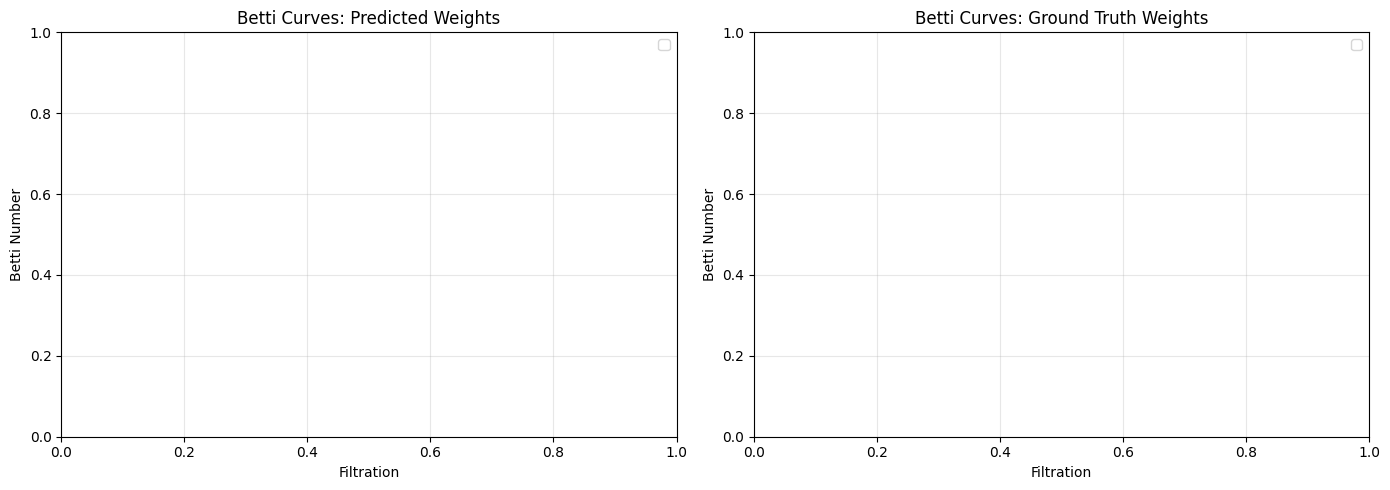


Betti Curve Distances:


In [7]:
# Compute Betti curves
betti_analyzer = BettiCurveAnalyzer(n_bins=50, max_dimension=2)

print("Computing Betti curves...")
betti_curves_pred = betti_analyzer.compute_betti_curves(predicted_weights)
betti_curves_gt = betti_analyzer.compute_betti_curves(ground_truth_weights)

# Plot Betti curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted
ax = axes[0]
for dim, curve in betti_curves_pred.items():
    ax.plot(curve, label=f'$\\beta_{dim}$', linewidth=2)
ax.set_xlabel('Filtration')
ax.set_ylabel('Betti Number')
ax.set_title('Betti Curves: Predicted Weights')
ax.legend()
ax.grid(True, alpha=0.3)

# Ground truth
ax = axes[1]
for dim, curve in betti_curves_gt.items():
    ax.plot(curve, label=f'$\\beta_{dim}$', linewidth=2)
ax.set_xlabel('Filtration')
ax.set_ylabel('Betti Number')
ax.set_title('Betti Curves: Ground Truth Weights')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare Betti curves
print("\nBetti Curve Distances:")
for dim in range(3):
    if dim in betti_curves_pred and dim in betti_curves_gt:
        dist = betti_analyzer.compare_betti_curves(
            betti_curves_pred[dim], 
            betti_curves_gt[dim]
        )
        print(f"  H{dim}: {dist:.6f}")

## Random Matrix Theory Analysis

In [8]:
# Initialize RMT analyzer
rmt_analyzer = RandomMatrixAnalyzer()

print("Analyzing weight matrices with RMT...")
rmt_results = rmt_analyzer.analyze_all_layers(predicted_weights)

print("\nRMT Analysis Results:")
print("=" * 80)

for layer_name, results in rmt_results.items():
    if results['type'] == 'weight':
        print(f"\n{layer_name}:")
        print(f"  Shape: {results['shape']}")
        print(f"  Spectral radius: {results['spectral_radius']:.4f}")
        print(f"  Condition number: {results['condition_number']:.4f}")
        print(f"  Effective rank: {results['effective_rank']:.2f}")
        print(f"  KL divergence from Marchenko-Pastur: {results['kl_divergence_from_mp']:.4f}")

Analyzing weight matrices with RMT...

RMT Analysis Results:

conv1_weight:
  Shape: (8, 25)
  Spectral radius: 0.4249
  Condition number: 10.5588
  Effective rank: 6.67
  KL divergence from Marchenko-Pastur: 2.5257

conv2_weight:
  Shape: (6, 200)
  Spectral radius: 2.6005
  Condition number: 1.7235
  Effective rank: 5.90
  KL divergence from Marchenko-Pastur: 2.8134

conv3_weight:
  Shape: (4, 24)
  Spectral radius: 0.3801
  Condition number: 3.4090
  Effective rank: 3.62
  KL divergence from Marchenko-Pastur: 3.2189

fc1_weight:
  Shape: (20, 36)
  Spectral radius: 0.9485
  Condition number: 22.6970
  Effective rank: 15.41
  KL divergence from Marchenko-Pastur: 1.6094

fc2_weight:
  Shape: (10, 20)
  Spectral radius: 0.3524
  Condition number: 16.3585
  Effective rank: 7.94
  KL divergence from Marchenko-Pastur: 20.5944


## Spectral Density Visualization

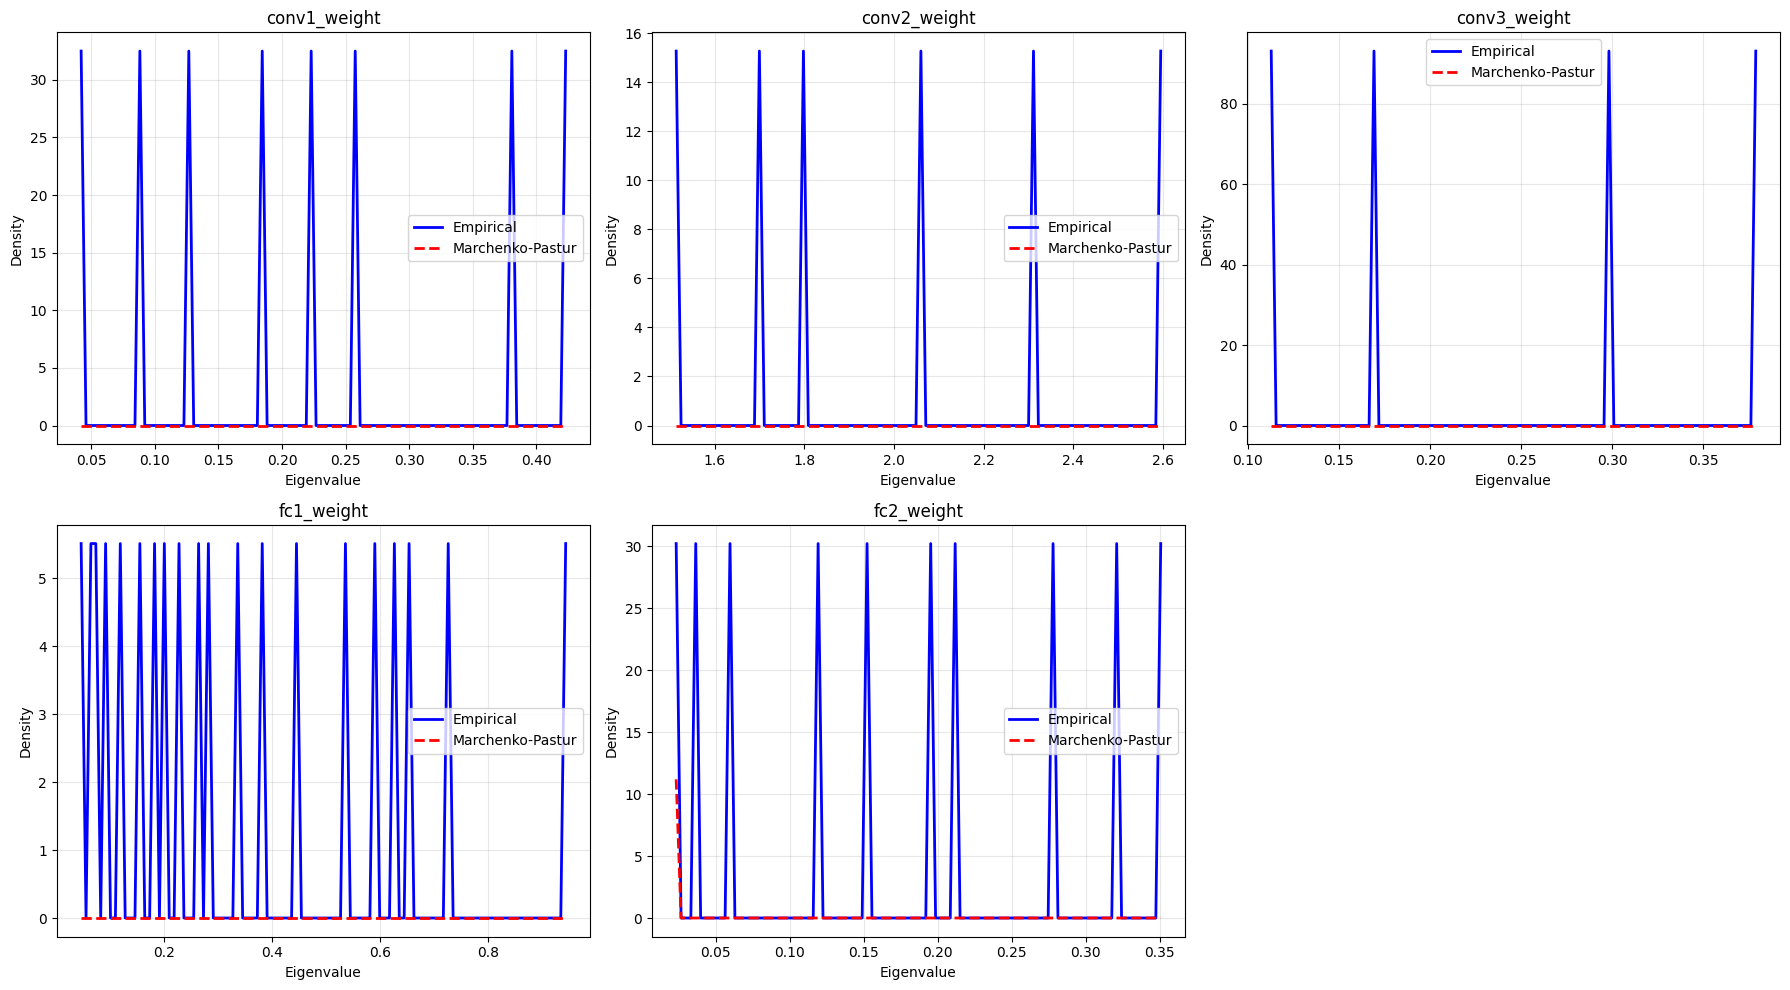

In [9]:
# Extract weight matrices
matrices = rmt_analyzer.extract_weight_matrices(predicted_weights)

# Plot spectral densities for each layer
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

layer_idx = 0
for layer_name, matrix in matrices.items():
    if 'weight' in layer_name and layer_idx < 6:
        ax = axes[layer_idx]
        
        results = rmt_analyzer.analyze_layer(matrix, layer_name)
        
        # Plot empirical density
        ax.plot(results['spectral_bins'], results['spectral_density'],
               'b-', linewidth=2, label='Empirical')
        
        # Plot Marchenko-Pastur
        ax.plot(results['spectral_bins'], results['mp_density'],
               'r--', linewidth=2, label='Marchenko-Pastur')
        
        ax.set_xlabel('Eigenvalue')
        ax.set_ylabel('Density')
        ax.set_title(f'{layer_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        layer_idx += 1

# Hide unused subplots
for idx in range(layer_idx, 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Comprehensive Weight Comparison Test

Running comprehensive weight comparison...

COMPREHENSIVE WEIGHT COMPARISON TEST
Computing basic metrics...
Computing topological features...
Computing RMT features...

SUMMARY
predicted_l2_error                      : 2.540901
finetuned_l2_error                      : 2.727650
improvement_ratio                       : 0.931535
predicted_cosine_sim                    : 0.886669
finetuned_cosine_sim                    : 0.868916
rmt_conv1_weight_wasserstein            : 0.072379
rmt_conv2_weight_wasserstein            : 0.490266
rmt_conv3_weight_wasserstein            : 0.068018
rmt_fc1_weight_wasserstein              : 0.097300
rmt_fc2_weight_wasserstein              : 0.070503
Results saved to results/demo_comparison/comparison_results.json

Creating visualizations...
Plot saved to results/demo_comparison/comparison_plot.png

TEST COMPLETE!
Results saved to results/demo_comparison


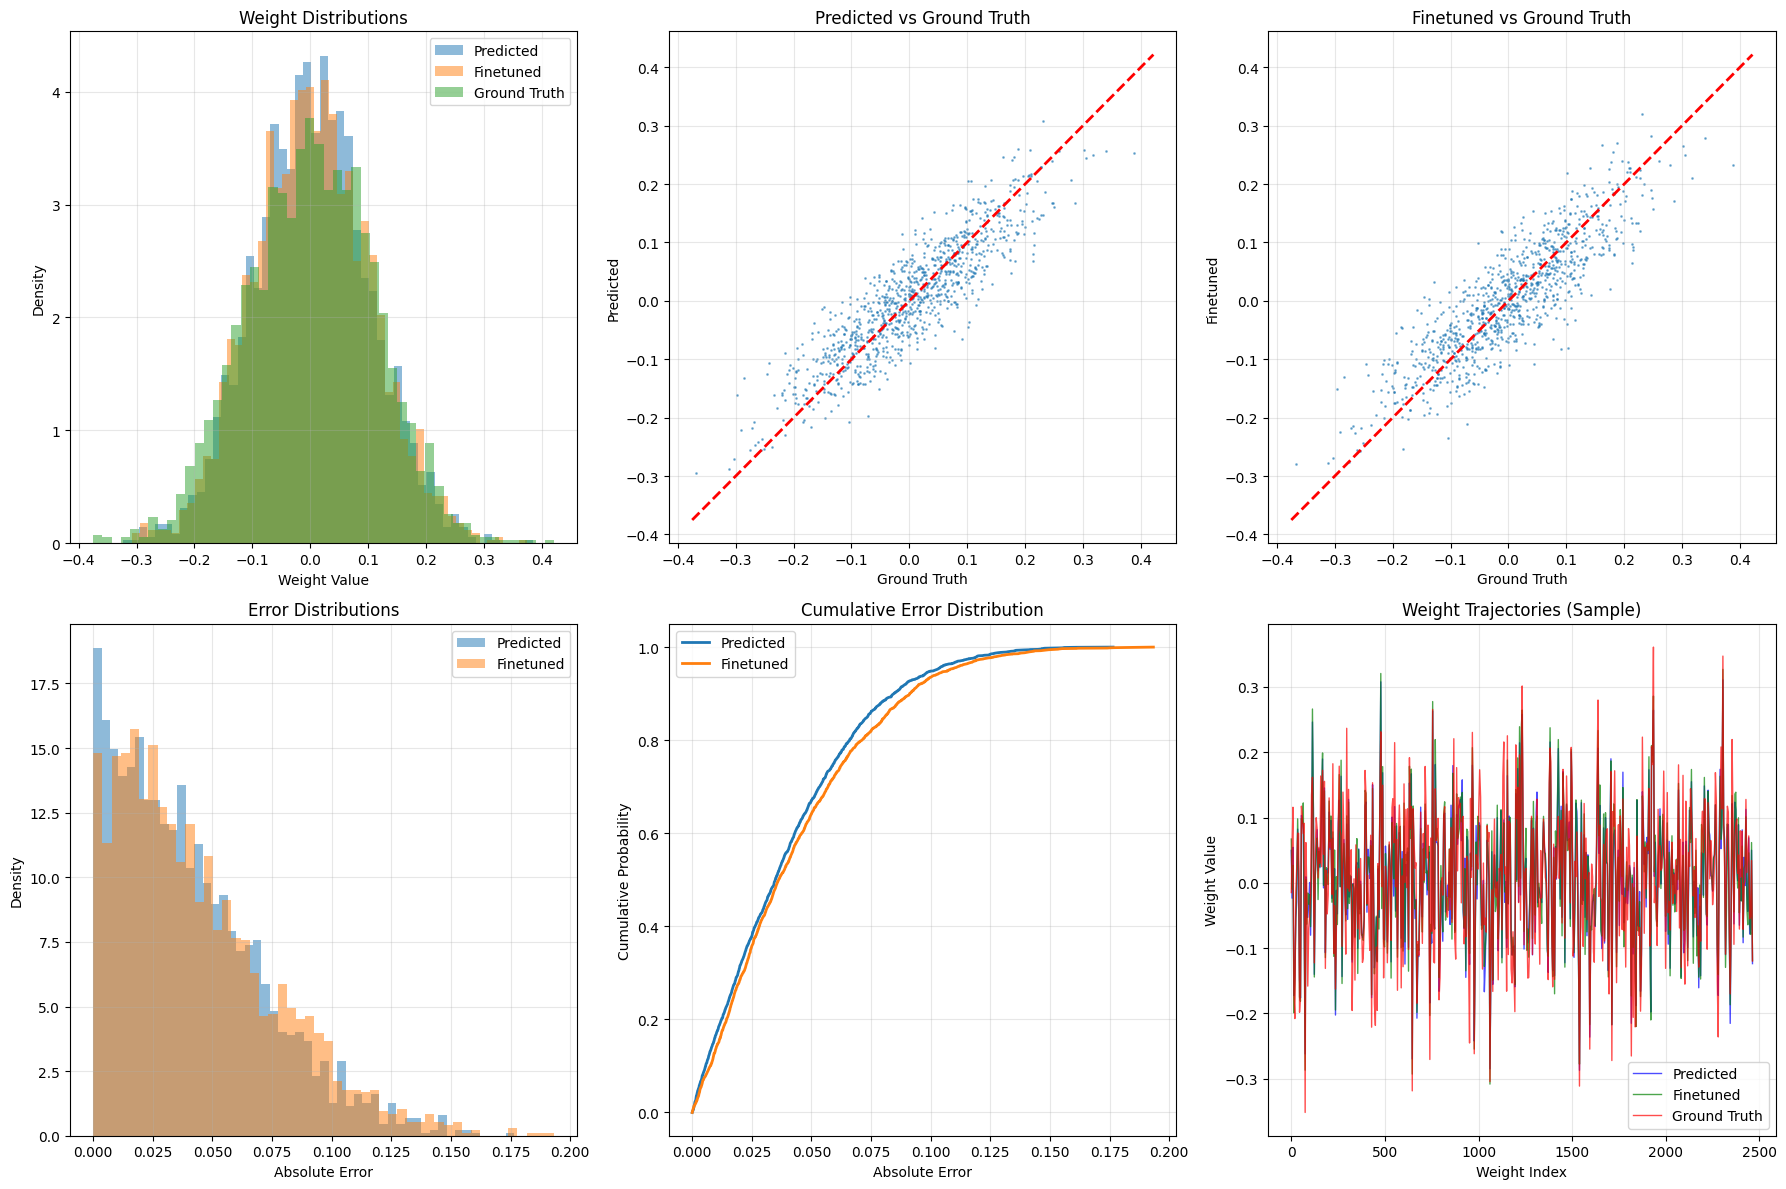

In [10]:
# Run comprehensive comparison
print("Running comprehensive weight comparison...")

results = run_comprehensive_test(
    predicted_weights,
    finetuned_weights,
    ground_truth_weights,
    save_dir="./results/demo_comparison"
)

## Experiment Suite Overview

View all predefined experiments

In [11]:
print("Predefined Experiment Suite:")
print("=" * 80)

experiment_summary = []

for exp_name, exp_config in EXPERIMENT_SUITE.items():
    model_config = exp_config.model
    model = create_model_from_config(model_config)
    params = model.count_parameters()
    
    experiment_summary.append({
        'name': exp_name,
        'model_size': model_config.name,
        'params_M': params / 1e6,
        'overlap': exp_config.data.overlap_levels[0],
        'loss': exp_config.loss.primary_loss,
        'epochs': exp_config.training.epochs,
    })
    
    del model
    torch.cuda.empty_cache()

df_experiments = pd.DataFrame(experiment_summary)
df_experiments

Predefined Experiment Suite:


,name,model_size,params_M,overlap,loss,epochs
0,quick_tiny_mse,tiny,4.020752,2,mse,100
1,quick_tiny_wasserstein,tiny,4.020752,2,wasserstein,100
2,small_mse_overlap2,small,8.322112,2,mse,100
3,small_mse_overlap1,small,8.322112,1,mse,100
4,small_mse_overlap0,small,8.322112,0,mse,100
5,small_wasserstein_overlap2,small,8.322112,2,wasserstein,100
6,small_lwwn_overlap2,small,8.322112,2,lwwn,100
7,small_mape_overlap2,small,8.322112,2,mape,100
8,medium_multi_overlap2,medium,18.063968,2,mse,100
9,medium_multi_overlap1,medium,18.063968,1,mse,100


## Summary and Next Steps

### Implemented Features:

1. **Optimized Model Architectures** (500K - 200M+ parameters)
   - Tiny: ~500K params - rapid prototyping
   - Small: ~2M params - fast training
   - Medium: ~8M params - balanced
   - Large: ~25M params - high capacity
   - Huge: 200M+ params - comparison with original

2. **Comprehensive Loss Functions**
   - MSE (Mean Squared Error)
   - MAPE (Mean Absolute Percentage Error)
   - AUTO (Autoencoder with regularization)
   - LWWN (Layer-Wise Weighted Norm)
   - LWWN-WS (with Weight Standardization)
   - Wasserstein Distance (Sliced)
   - Latent Loss (smoothness + sparsity)
   - Multi-Loss (weighted combination)

3. **Persistent Homology Analysis**
   - Persistence diagrams
   - Betti curves
   - Vectorizable topological features
   - Diagram comparison metrics

4. **Random Matrix Theory Metrics**
   - Eigenvalue distributions
   - Spectral density
   - Marchenko-Pastur law comparison
   - Condition numbers and effective rank

5. **Training Infrastructure**
   - Mixed precision training (AMP)
   - Gradient checkpointing
   - WandB integration
   - Early stopping
   - Learning rate scheduling

6. **Data Preprocessing**
   - Varying class overlap (2, 1, 0)
   - Pre-saved TensorDatasets
   - Train/val/test splits

### To Run Full Experiments:

1. **Preprocess Data**:
   ```python
   python data_preprocessing.py
   ```

2. **Run Experiments**:
   ```python
   python -c "from trainer import *; from config import *; ..."
   ```

3. **Analyze Results**:
   Use the testing suite to compare predicted, finetuned, and ground truth weights

### Recommended Experiment Order:

1. **Quick validation**: tiny model, MSE loss, overlap=2
2. **Loss function comparison**: small model, all losses, overlap=2
3. **Overlap analysis**: small model, MSE, overlap=[2,1,0]
4. **Scale up**: medium/large models with best-performing configurations
5. **Final comparison**: huge model vs best optimized model